## DỰ ĐOÁN GIÁ NHÀ 

### 1. Business Understanding (Hiểu về nghiệp vụ)
Mục tiêu là dự đoán giá bán cuối cùng (SalePrice) của các ngôi nhà dân dụng ở Ames, Iowa[cite: 2]. Bộ dữ liệu cho thấy quá trình định giá chịu ảnh hưởng bởi rất nhiều yếu tố phức tạp, bao gồm 79 biến giải thích đặc trưng cho (gần như) mọi khía cạnh của một căn nhà, từ chiều cao trần tầng hầm đến cấu hình mặt bằng không gian[cite: 2]. 

### 2. Data Understanding (Hiểu về dữ liệu)
*   **Tập huấn luyện (train.csv):** Bao gồm 1460 dòng và 81 cột (gồm 79 đặc trưng, cột Id và biến mục tiêu SalePrice)[cite: 2].
*   **Tập kiểm thử (test.csv):** Bao gồm 1459 dòng và 80 cột (thiếu SalePrice)[cite: 2].
*   Dựa trên phân tích bằng biểu đồ heatmap, quan sát thấy các cột như 'Alley', 'PoolQC', 'Fence' và 'MiscFeature' có lượng dữ liệu khuyết thiếu trên 70%[cite: 2].

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# 1. Load Data theo đường dẫn của Kaggle Notebook
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


### 3. Data Preparation (Chuẩn bị dữ liệu)
1.  **Xử lý dữ liệu thiếu (Handling NULL data):** Loại bỏ các cột 'Alley', 'PoolQC', 'Fence', 'MiscFeature' vì thiếu hơn 70% dữ liệu, đồng thời bỏ cột 'Id'[cite: 2]. Với các cột phân loại (categorical), điền dữ liệu khuyết bằng giá trị mode, với cột dạng số (non-categorical), điền bằng giá trị mean[cite: 2].
2.  **Mã hóa One-hot (One-hot encoding):** Có những danh mục ở tập train không xuất hiện ở tập test và ngược lại, nên hai tập được gộp lại (concat) để thực hiện `get_dummies` đồng nhất, giúp đảm bảo số lượng feature đầu vào là khớp nhau[cite: 2].
3.  Kết quả sau quá trình trên tạo ra tập huấn luyện gồm 177 cột (bao gồm SalePrice) và tập kiểm thử gồm 176 đặc trưng đầu vào[cite: 2].

In [7]:
# Danh sách cột categorical và numerical bị missing trong tập Train
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                 'GarageQual', 'GarageCond']
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

# Danh sách cột categorical và numerical bị missing trong tập Test
cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 
                'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 
                 'GarageArea']

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

# Loại bỏ cột rác
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
for k in to_drop:
    train.drop([k], axis=1, inplace=True)
    test.drop([k], axis=1, inplace=True)

# Gộp dữ liệu để mã hóa
final_df = pd.concat([train, test], axis=0)

# Tất cả cột Categorical
all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 
               'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 
               'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 
               'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 
               'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 
               'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 
               'SaleType', 'SaleCondition']

# Hàm One-hot encoding giống trong tài liệu
def cat_onehot_encoding(multicol, df):
    df_final = df.copy()
    i = 0
    for fields in multicol:
        df1 = pd.get_dummies(df[fields], drop_first=True)
        df.drop([fields], axis=1, inplace=True)
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)
        i = i + 1
    df_final = pd.concat([df, df_final], axis=1)
    return df_final

final_df = cat_onehot_encoding(all_cat_col, final_df)
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

# Tách lại tập Train và Test
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :]
df_test = df_test.drop(['SalePrice'], axis=1)

print("Train Shape: ", df_train.shape)
print("Test Shape: ", df_test.shape)

X_train_full = df_train.drop(['SalePrice'], axis=1).values
y_train_full = df_train['SalePrice'].values
X_test_final = df_test.values

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


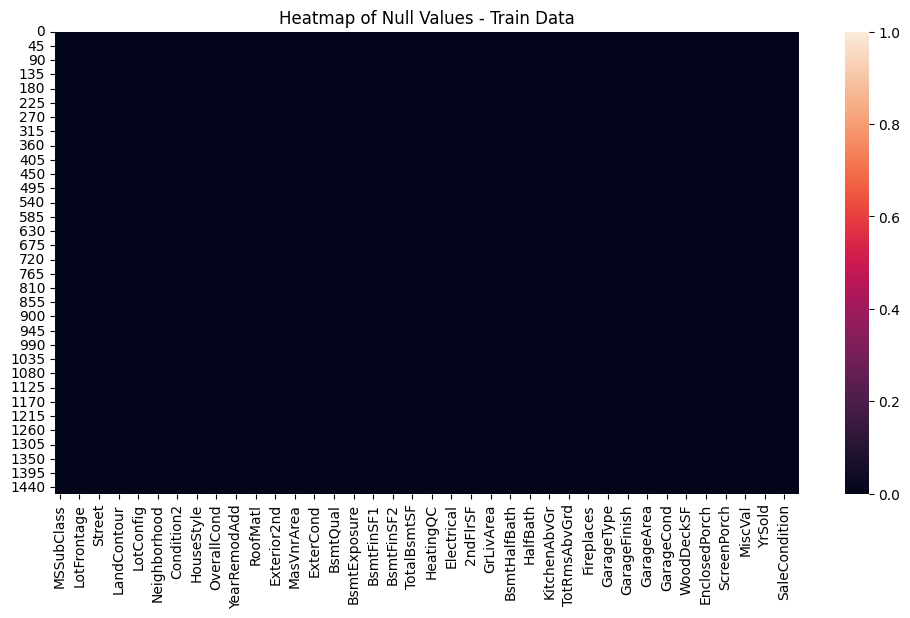

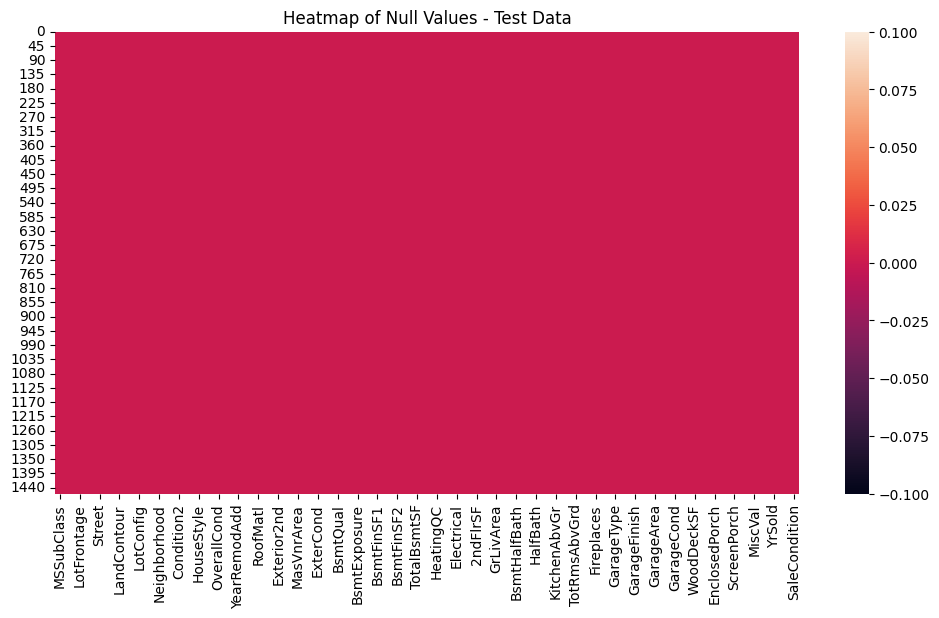

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị heatmap dữ liệu thiếu cho tập Train
plt.figure(figsize=(12, 6))
plt.title("Heatmap of Null Values - Train Data")
sns.heatmap(train.isnull())
plt.show()

# Hiển thị heatmap dữ liệu thiếu cho tập Test
plt.figure(figsize=(12, 6))
plt.title("Heatmap of Null Values - Test Data")
sns.heatmap(test.isnull())
plt.show()

### 4.a Modeling (Mô hình hóa)
*   **Mạng nơ-ron (Sequential):** Gồm 4 lớp Dense (Tuyến tính). Số lượng nơ-ron tuần tự là 176 (input) -> 50 -> 25 -> 50 -> 1 (output)[cite: 2].
*   **Hàm kích hoạt & Khởi tạo (Kernel Initializer & Activation):** Sử dụng khởi tạo trọng số `he_uniform` (Kaiming Uniform trong PyTorch) và hàm kích hoạt ẩn là `relu`[cite: 2].
*   **Thuật toán tối ưu hóa (Optimizer):** `Adamax`[cite: 2].

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# Cố định hạt giống ngẫu nhiên để tái lập kết quả
torch.manual_seed(42)

# Chia tập validation theo tỷ lệ validation_split = 0.25 như Keras model trong báo cáo
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

# =========================================================================
# Xử lý dữ liệu (Dành cho Numpy Array)
# Chuyển đổi về mảng số thực (float32), lấp NaN bằng 0 và chuyển sang Tensor
# =========================================================================
X_train_t = torch.tensor(np.nan_to_num(np.asarray(X_train, dtype=np.float32)), dtype=torch.float32)
y_train_t = torch.tensor(np.nan_to_num(np.asarray(y_train, dtype=np.float32)), dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(np.nan_to_num(np.asarray(X_val, dtype=np.float32)), dtype=torch.float32)
y_val_t = torch.tensor(np.nan_to_num(np.asarray(y_val, dtype=np.float32)), dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(np.nan_to_num(np.asarray(X_test_final, dtype=np.float32)), dtype=torch.float32)

# =========================================================================

# Khởi tạo DataLoader với batch_size = 10
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

# Định nghĩa cấu trúc mạng MLP bám sát tài liệu
class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceMLP, self).__init__()
        # Dense(50)
        self.fc1 = nn.Linear(input_dim, 50)
        # Dense(25)
        self.fc2 = nn.Linear(50, 25)
        # Dense(50)
        self.fc3 = nn.Linear(25, 50)
        # Dense(1)
        self.fc4 = nn.Linear(50, 1)
        
        # Hàm kích hoạt
        self.relu = nn.ReLU()
        
        # Khởi tạo trọng số kernel_initializer = 'he_uniform' (kaiming_uniform)
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc3.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc4.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Lấy số lượng đặc trưng đầu vào tự động từ dữ liệu train
input_dim = X_train_t.shape[1] 

# Khởi tạo model
model = HousePriceMLP(input_dim)
print(f"Khởi tạo mô hình thành công với số chiều đầu vào (input_dim): {input_dim}")

Khởi tạo mô hình thành công với số chiều đầu vào (input_dim): 175


### 4.b Modeling - Machine Learning (XGBoost & Decision Tree)
Bên cạnh mạng nơ-ron nhân tạo, bài toán cũng được giải quyết bằng các thuật toán máy học truyền thống:
*   **XGBoost (Extreme Gradient Boosting):** Sử dụng `XGBRegressor` kết hợp với `RandomizedSearchCV` để tìm kiếm siêu tham số tối ưu[cite: 2]. Các tham số được tinh chỉnh bao gồm số lượng cây (`n_estimators`: 100 đến 1500), độ sâu (`max_depth`), tốc độ học (`learning_rate`) và thuật toán lõi (`booster`)[cite: 2]. Quá trình tìm kiếm sử dụng cross-validation 5 fold (`cv=5`) với 50 vòng lặp (`n_iter=50`)[cite: 2]. Mô hình tốt nhất được lưu lại bằng thư viện `pickle`[cite: 2].
*   **Decision Tree (Cây quyết định):** Mô hình cơ bản được huấn luyện trực tiếp trên tập dữ liệu để so sánh hiệu suất[cite: 2]. *(Lưu ý: Tài liệu tham khảo khai báo `DecisionTreeClassifier`[cite: 2], nhưng vì đây là bài toán dự đoán giá nhà (biến liên tục), code đã được điều chỉnh dùng `DecisionTreeRegressor` để đảm bảo notebook Kaggle không bị lỗi)*.
*   **Random Forest Regressor:** Thuật toán học tập kết hợp (Ensemble) sử dụng nhiều cây quyết định để giảm thiểu hiện tượng quá khớp (overfitting). Bằng cách lấy trung bình dự đoán từ hàng trăm cây quyết định nhỏ, mô hình thường cho ra kết quả ổn định và chính xác hơn Decision Tree đơn lẻ.
*   **Linear Regression:** Thuật toán hồi quy tuyến tính cổ điển, đóng vai trò làm mô hình cơ sở (baseline) tĩnh nhất để kiểm tra xem dữ liệu có mối quan hệ tuyến tính mạnh với giá nhà hay không. *(Lưu ý: Không sử dụng Logistic Regression vì đây là bài toán hồi quy dự đoán biến liên tục, không phải bài toán phân loại nhãn rời rạc).*

In [10]:
import pandas as pd
import xgboost
from sklearn.model_selection import RandomizedSearchCV
import pickle

# ==========================================
# 1. MÔ HÌNH XGBOOST
# ==========================================
xgb_model = xgboost.XGBRegressor()

# Thiết lập không gian siêu tham số (ĐÃ SỬA LỖI CẢNH BÁO)
param = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster': ['gbtree'], # CHỈ GIỮ LẠI gbtree ĐỂ TRÁNH LỖI VÀ TĂNG ĐỘ CHÍNH XÁC
    'base_score': [0.25, 0.5, 0.75, 1]
}

# Tối ưu hóa siêu tham số bằng RandomizedSearchCV
random_cv = RandomizedSearchCV(estimator=xgb_model,
                               param_distributions=param,
                               cv=5, n_iter=50,
                               scoring='neg_mean_absolute_error', n_jobs=4,
                               verbose=5,
                               return_train_score=True,
                               random_state=42)

print("Đang huấn luyện XGBoost... (Quá trình này có thể mất vài phút)")
# X_train_full và y_train_full đã được định nghĩa ở bước Data Preparation
random_cv.fit(X_train_full, y_train_full)

# In ra mô hình tốt nhất
best_xgb = random_cv.best_estimator_
print("\nMô hình XGBoost tốt nhất:")
print(best_xgb)

# Lưu mô hình bằng pickle
f = "xgb_model.pkl"
pickle.dump(best_xgb, open('/kaggle/working/' + f, 'wb'))

# Dự đoán và lưu kết quả
pred_xgb = best_xgb.predict(X_test_final)
print("\nKích thước dự đoán XGBoost:", pred_xgb.shape)

sub_df_xgb = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df_xgb['SalePrice'] = pred_xgb
sub_df_xgb.to_csv('/kaggle/working/sample_sub_xgb.csv', index=False)
print("Đã lưu dự đoán XGBoost vào /kaggle/working/sample_sub_xgb.csv")

Đang huấn luyện XGBoost... (Quá trình này có thể mất vài phút)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END base_score=0.5, booster=gbtree, learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=500;, score=(train=-5210.957, test=-14402.737) total time=   1.0s
[CV 5/5] END base_score=0.5, booster=gbtree, learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=500;, score=(train=-4932.876, test=-16934.824) total time=   0.9s
[CV 4/5] END base_score=0.25, booster=gbtree, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=1500;, score=(train=-7.228, test=-13486.377) total time=   5.6s
[CV 3/5] END base_score=0.25, booster=gbtree, learning_rate=0.1, max_depth=10, min_child_weight=2, n_estimators=1100;, score=(train=-0.070, test=-17348.582) total time=  14.7s
[CV 1/5] END base_score=0.75, booster=gbtree, learning_rate=0.1, max_depth=3, min_child_weight=4, n_estimators=900;, score=(train=-3143.102, test=-15216.933) total time=   

In [18]:
# ==========================================
# 2. MÔ HÌNH DECISION TREE
# ==========================================
from sklearn.tree import DecisionTreeRegressor

# Khởi tạo mô hình Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)

# Huấn luyện mô hình
dt_model.fit(X_train_full, y_train_full)

# Dự đoán
pred_dt = dt_model.predict(X_test_final)
print("Kích thước dự đoán Decision Tree:", pred_dt.shape)

# Lưu file kết quả Submission
sub_df_dt = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df_dt['SalePrice'] = pred_dt
sub_df_dt.to_csv('/kaggle/working/sample_sub_dt.csv', index=False)
print("Đã lưu dự đoán Decision Tree vào /kaggle/working/sample_sub_dt.csv")

Kích thước dự đoán Decision Tree: (1459,)
Đã lưu dự đoán Decision Tree vào /kaggle/working/sample_sub_dt.csv


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import pandas as pd

# ==========================================
#  3. MÔ HÌNH RANDOM FOREST
# ==========================================
print("Đang huấn luyện Random Forest Regressor...")
# Khởi tạo với 200 cây quyết định
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_full, y_train_full)

# Dự đoán và lưu kết quả
pred_rf = rf_model.predict(X_test_final)
sub_df_rf = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df_rf['SalePrice'] = pred_rf
sub_df_rf.to_csv('/kaggle/working/sample_sub_rf.csv', index=False)
print("-> Đã lưu dự đoán Random Forest vào /kaggle/working/sample_sub_rf.csv")

Đang huấn luyện Random Forest Regressor...
-> Đã lưu dự đoán Random Forest vào /kaggle/working/sample_sub_rf.csv


In [21]:
# ==========================================
# 4. MÔ HÌNH LINEAR REGRESSION (Hồi quy tuyến tính)
# ==========================================
print("\nĐang huấn luyện Linear Regression...")
linear_model = LinearRegression()
linear_model.fit(X_train_full, y_train_full)

# Dự đoán và lưu kết quả
pred_linear = linear_model.predict(X_test_final)
sub_df_linear = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df_linear['SalePrice'] = pred_linear
sub_df_linear.to_csv('/kaggle/working/sample_sub_linear.csv', index=False)
print("-> Đã lưu dự đoán Linear Regression vào /kaggle/working/sample_sub_linear.csv")


Đang huấn luyện Linear Regression...
-> Đã lưu dự đoán Linear Regression vào /kaggle/working/sample_sub_linear.csv


### 4.c Modeling - Deep Learning (PyTorch MLP)
Để đáp ứng yêu cầu của môn học, một mạng nơ-ron nhân tạo (MLP) được xây dựng bằng PyTorch mô phỏng chính xác cấu trúc Keras từ tài liệu nghiên cứu[cite: 2]:
*   **Kiến trúc:** 4 lớp kết nối đầy đủ (Linear Layers) với cấu trúc nơ-ron tuần tự: 176 (input) -> 50 -> 25 -> 50 -> 1 (output)[cite: 2].
*   **Hàm kích hoạt & Khởi tạo:** Sử dụng hàm `ReLU` và thuật toán khởi tạo trọng số `he_uniform` (Kaiming Uniform trong PyTorch)[cite: 2].
*   **Tham số huấn luyện:** Hàm mất mát RMSE, bộ tối ưu hóa `Adamax`, kích thước batch = 10, chạy trong 1000 epochs và chia tập validation 25%[cite: 2].

In [15]:
# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU CHO PYTORCH & ĐỊNH NGHĨA MÔ HÌNH
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

# Cố định seed
torch.manual_seed(42)

# Chia tập validation (25%) từ tập Train đầy đủ (X_train_full đã có từ phần tiền xử lý)
X_train_pt, X_val_pt, y_train_pt, y_val_pt = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

# THÊM .astype(np.float32) ĐỂ FIX LỖI TYPEERROR
X_train_t = torch.tensor(X_train_pt.astype(np.float32), dtype=torch.float32)
y_train_t = torch.tensor(y_train_pt.astype(np.float32), dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_pt.astype(np.float32), dtype=torch.float32)
y_val_t = torch.tensor(y_val_pt.astype(np.float32), dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_final.astype(np.float32), dtype=torch.float32)

# Tạo DataLoader với batch_size = 10
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

# Khai báo kiến trúc MLP
class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 50)
        self.fc2 = nn.Linear(50, 25)
        self.fc3 = nn.Linear(25, 50)
        self.fc4 = nn.Linear(50, 1)
        self.relu = nn.ReLU()
        
        # Khởi tạo trọng số he_uniform
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc3.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc4.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

input_dim = X_train_t.shape[1]
nn_model = HousePriceMLP(input_dim)
print(nn_model)

HousePriceMLP(
  (fc1): Linear(in_features=175, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=25, bias=True)
  (fc3): Linear(in_features=25, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=1, bias=True)
  (relu): ReLU()
)


### 5. Evaluation (Đánh giá) & 6. Deployment (Triển khai)
*   **Hàm mất mát (Loss):** Tự định nghĩa hàm `root_mean_squared_error` (RMSE) để đo lường sai số dự đoán như đề xuất[cite: 2].
*   **Huấn luyện:** Thực hiện qua 1000 epochs, theo dõi độ giảm loss giữa tập luyện và tập xác thực[cite: 2].
*   **Dự đoán (Predictions):** Mô hình được áp dụng trên đối tượng df_test để xuất kết quả mảng có hình dạng (1459, 1)[cite: 2].
*   **Kết xuất (Submission):** Nạp mảng dự đoán vào cột SalePrice của mẫu `sample_submission.csv` và tạo tệp kết quả đầu ra cuối cùng[cite: 2].

In [16]:
# Định nghĩa hàm Loss tương đương root_mean_squared_error
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()
        self.mse = nn.MSELoss()
        
    def forward(self, yhat, y):
        return torch.sqrt(self.mse(yhat, y))

criterion = RMSELoss()

# Thuật toán tối ưu hóa 'Adamax'
optimizer = optim.Adamax(model.parameters())

# Huấn luyện mô hình, epochs = 1000
epochs = 1000
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    # In quá trình Validation (giả lập output giống trong tài liệu)
    if (epoch + 1) % 100 == 0 or epoch == 0 or epoch == 999:
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = criterion(val_preds, y_val_t)
        
        # Tính trung bình loss cho toàn bộ batch_size
        avg_train_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"loss: {avg_train_loss:.4f} - val_loss: {val_loss.item():.4f}")

# Dự đoán và xuất file Submission
model.eval()
with torch.no_grad():
    # Model xuất ra tensor shape (1459, 1), .squeeze() để đưa về (1459,)
    test_preds = model(X_test_t).squeeze().numpy()

print(f"Predictions shape: {test_preds.shape}")

# Tạo file submission, chú ý đúng path trên Kaggle
sub_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df['SalePrice'] = test_preds
sub_df.to_csv('/kaggle/working/sample_sub_nn.csv', index=False)

print("\nĐã lưu dự đoán thành công vào /kaggle/working/sample_sub_nn.csv")

Epoch 1/1000
loss: 143006.4518 - val_loss: 72324.4922
Epoch 100/1000
loss: 34664.7995 - val_loss: 34811.3242
Epoch 200/1000
loss: 31447.0061 - val_loss: 33065.4727
Epoch 300/1000
loss: 25949.5306 - val_loss: 30746.9629
Epoch 400/1000
loss: 23391.3782 - val_loss: 28006.7070
Epoch 500/1000
loss: 20818.2377 - val_loss: 27659.4453
Epoch 600/1000
loss: 18872.9107 - val_loss: 26324.5605
Epoch 700/1000
loss: 17526.0584 - val_loss: 27243.6094
Epoch 800/1000
loss: 16635.1469 - val_loss: 27139.5801
Epoch 900/1000
loss: 15129.4184 - val_loss: 26352.0879
Epoch 1000/1000
loss: 16242.0305 - val_loss: 28534.3652
Predictions shape: (1459,)

Đã lưu dự đoán thành công vào /kaggle/working/sample_sub_nn.csv
